# COMP0258 Demo Notebook

This notebook is our research demo.

- The VAE section focuses on latent perturbation, repaired decoding, and a lightweight CMA-ES search demo in latent space. We also add in a section which evaluates a trained maze agent on the fixed prefab test mazes.

- The LLM Section focusses on DAWDHSUIsDKjANSKDjnaszkjdnkaJDNjkasndkjsakjNDKJNaSJK

In [ ]:
# ── Colab-only: clone repo, install deps, download assets ──
# Skip this cell when running locally.
import os
if os.path.exists('/content') and not os.path.exists('/content/superintelligence'):
    !git clone -b Notebook https://github.com/khyledhanani/superintelligence.git /content/superintelligence
    !pip install -e /content/superintelligence[examples] matplotlib plotly cma absl-py PyYAML

# After running this cell, upload your assets into /content/superintelligence/notebooks/assets/:
#   - cluttr_vae_aligned_checkpoint_2060000.pkl
#   - cluttr_envs_20k.npy
#   - models/  (agent checkpoint directory)
#
# You can do this via the Colab Files pane, or by mounting Google Drive:
#   from google.colab import drive
#   drive.mount('/content/drive')
#   !cp -r /content/drive/MyDrive/<your_assets_folder>/* /content/superintelligence/notebooks/assets/

In [41]:
import importlib.util
import os
import subprocess
import sys
from pathlib import Path

_nb = globals().get('__vsc_ipynb_file__')
PROJECT_ROOT = Path(_nb).resolve().parent.parent if _nb else Path('/content/superintelligence')
ASSET_DIR = PROJECT_ROOT / 'notebooks' / 'assets'
VAE_CHECKPOINT_PATH = ASSET_DIR / 'cluttr_vae_aligned_checkpoint_2060000.pkl'
TRAINING_STYLE_DATASET_PATH = ASSET_DIR / 'cluttr_envs_20k.npy'
AGENT_CHECKPOINT_DIR = ASSET_DIR / 'models'

os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
if str(PROJECT_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / 'src'))

LATENT_MODE = 'scaled'
PARENT_INDEX = 12
CMA_STEPS = 10
CMA_POPSIZE = 16
ROLLOUT_STEPS = 250
TEST_LEVEL_NAMES = [
    'NarrowBridge', 'ForkDeception', 'PerimeterRun', 'SpiralPocket', 'SymmetricCross',
    'ZigZagTunnel', 'RoomKeyhole', 'DualLoopChoice', 'CentralChoke', 'LongDetour',
    'DeadendFan', 'OpenFieldBarriers', 'ParallelCorridors', 'CornerTrapEscape', 'SnakeSpine',
]

print('PROJECT_ROOT =', PROJECT_ROOT)
print('ASSET_DIR =', ASSET_DIR)
print('VAE_CHECKPOINT_PATH =', VAE_CHECKPOINT_PATH)
print('TRAINING_STYLE_DATASET_PATH =', TRAINING_STYLE_DATASET_PATH)
print('AGENT_CHECKPOINT_DIR =', AGENT_CHECKPOINT_DIR)


PROJECT_ROOT = /Users/khyledhanani/Documents/openend/superintelligence
ASSET_DIR = /Users/khyledhanani/Documents/openend/superintelligence/notebooks/assets
VAE_CHECKPOINT_PATH = /Users/khyledhanani/Documents/openend/superintelligence/notebooks/assets/cluttr_vae_aligned_checkpoint_2060000.pkl
TRAINING_STYLE_DATASET_PATH = /Users/khyledhanani/Documents/openend/superintelligence/notebooks/assets/cluttr_envs_20k.npy
AGENT_CHECKPOINT_DIR = /Users/khyledhanani/Documents/openend/superintelligence/notebooks/assets/models


In [42]:
import pickle
from collections import deque

import absl.logging
import cma
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import plotly.graph_objects as go
from flax import linen as nn
from matplotlib.colors import ListedColormap

from es.agent_loader import ActorCritic, load_agent, verify_agent_contract
from jaxued.environments.maze import Maze
from jaxued.environments.maze.level import Level, prefabs

absl.logging.set_verbosity('error')

with open(VAE_CHECKPOINT_PATH, 'rb') as f:
    VAE_STATE = pickle.load(f)
VAE_PARAMS = VAE_STATE['params']
print('Loaded VAE step:', VAE_STATE.get('step'))
print('VAE run id:', VAE_STATE.get('run_id'))


class HighwayAligned(nn.Module):
    dim: int = 300

    def setup(self):
        self.dense_g = nn.Dense(self.dim)
        self.dense_fg = nn.Dense(self.dim)
        self.dense_q1 = nn.Dense(self.dim)
        self.dense_q2 = nn.Dense(self.dim)
        self.dense_gate = nn.Dense(self.dim)

    def __call__(self, x):
        g = nn.relu(self.dense_g(x))
        f_g_x = nn.relu(self.dense_fg(g))
        q_x = self.dense_q2(nn.relu(self.dense_q1(x)))
        gate = nn.sigmoid(self.dense_gate(x))
        return gate * f_g_x + (1.0 - gate) * q_x


class CluttrAlignedVAE(nn.Module):
    vocab_size: int = 170
    embed_dim: int = 300
    latent_dim: int = 64
    seq_len: int = 52

    def setup(self):
        self.embed = nn.Embed(self.vocab_size, self.embed_dim)
        self.enc_drop1 = nn.Dropout(rate=0.1)
        self.enc_hw1 = HighwayAligned(self.embed_dim)
        self.enc_hw2 = HighwayAligned(self.embed_dim)
        self.enc_bilstm = nn.Bidirectional(
            nn.RNN(nn.LSTMCell(300)),
            nn.RNN(nn.LSTMCell(300)),
        )
        self.enc_drop2 = nn.Dropout(rate=0.1)
        self.mean_layer = nn.Dense(self.latent_dim)
        self.logvar_layer = nn.Dense(self.latent_dim)
        self.dec_bilstm1 = nn.Bidirectional(
            nn.RNN(nn.LSTMCell(400)),
            nn.RNN(nn.LSTMCell(400)),
        )
        self.dec_bilstm2 = nn.Bidirectional(
            nn.RNN(nn.LSTMCell(400)),
            nn.RNN(nn.LSTMCell(400)),
        )
        self.dec_output = nn.Dense(self.vocab_size)

    def encode(self, x, train: bool = False, return_pretanh: bool = False):
        x = self.embed(x)
        x = self.enc_drop1(x, deterministic=not train)
        x = self.enc_hw1(x)
        x = self.enc_hw2(x)
        outputs = self.enc_bilstm(x)
        outputs = self.enc_drop2(outputs, deterministic=not train)

        fwd_out = outputs[:, :, :300]
        bwd_out = outputs[:, :, 300:]
        h = jnp.concatenate([fwd_out[:, -1, :], bwd_out[:, 0, :]], axis=-1)

        mean_pretanh = self.mean_layer(h)
        mean = jnp.tanh(mean_pretanh) * 6.0
        logvar = jnp.clip(self.logvar_layer(h), -10.0, 4.0)
        if return_pretanh:
            return mean_pretanh, mean, logvar
        return mean, logvar

    def decode(self, z):
        squeeze = False
        if z.ndim == 1:
            z = z[jnp.newaxis, :]
            squeeze = True

        z_seq = jnp.tile(z[:, jnp.newaxis, :], (1, self.seq_len, 1))
        d_out = self.dec_bilstm1(z_seq)
        d_out = self.dec_bilstm2(d_out)
        logits = self.dec_output(d_out)

        if squeeze:
            logits = logits[0]
        return logits


VAE_MODEL = CluttrAlignedVAE()


@jax.jit
def encode_stats_jit(sequences):
    return VAE_MODEL.apply({'params': VAE_PARAMS}, sequences, method=CluttrAlignedVAE.encode, return_pretanh=True)


@jax.jit
def decode_logits_jit(z):
    return VAE_MODEL.apply({'params': VAE_PARAMS}, z, method=CluttrAlignedVAE.decode)


def encode_sequences(sequences, latent_mode=LATENT_MODE):
    sequences = np.asarray(sequences, dtype=np.int32)
    pretanh_mean, scaled_mean, _ = encode_stats_jit(jnp.asarray(sequences))
    if latent_mode == 'raw':
        return np.asarray(pretanh_mean, dtype=np.float32)
    if latent_mode == 'scaled':
        return np.asarray(scaled_mean, dtype=np.float32)
    raise ValueError(f'Unsupported latent mode: {latent_mode}')


def repair_cluttr_sequence(seq):
    seq = np.clip(np.asarray(seq, dtype=np.int32), 0, 169)
    goal = int(np.clip(seq[50], 1, 169))
    agent = int(np.clip(seq[51], 1, 169))
    if goal == agent:
        agent = (agent % 169) + 1
    obstacles = seq[:50].copy()
    obstacles[obstacles == goal] = 0
    obstacles[obstacles == agent] = 0
    obstacles = np.sort(obstacles)
    return np.concatenate([obstacles, np.array([goal, agent], dtype=np.int32)])


def decode_latents(z_batch, repair=True):
    z_batch = np.asarray(z_batch, dtype=np.float32)
    logits = np.asarray(decode_logits_jit(jnp.asarray(z_batch)), dtype=np.float32)
    sequences = np.argmax(logits, axis=-1).astype(np.int32)
    if repair:
        sequences = np.stack([repair_cluttr_sequence(seq) for seq in sequences], axis=0)
    return sequences


def summarize_raw_decoder_health(sequences):
    sequences = np.asarray(sequences, dtype=np.int32)
    goal = sequences[:, 50]
    agent = sequences[:, 51]
    return {
        'invalid_goal_rate': float(np.mean((goal < 1) | (goal > 169))),
        'invalid_agent_rate': float(np.mean((agent < 1) | (agent > 169))),
        'goal_eq_agent_rate': float(np.mean(goal == agent)),
    }


def idx_to_row_col(index, inner_dim=13):
    index = int(index) - 1
    return index // inner_dim, index % inner_dim


def sequence_to_grid(seq, inner_dim=13):
    grid = np.zeros((inner_dim, inner_dim), dtype=np.int32)
    for obs_idx in np.asarray(seq[:50], dtype=np.int32):
        if obs_idx > 0:
            row, col = idx_to_row_col(obs_idx, inner_dim)
            grid[row, col] = 1
    goal_row, goal_col = idx_to_row_col(seq[50], inner_dim)
    agent_row, agent_col = idx_to_row_col(seq[51], inner_dim)
    grid[goal_row, goal_col] = 2
    grid[agent_row, agent_col] = 3
    return grid


def level_to_grid(level):
    wall_map = np.asarray(level.wall_map, dtype=bool)
    grid = np.zeros(wall_map.shape, dtype=np.int32)
    grid[wall_map] = 1
    grid[int(level.goal_pos[1]), int(level.goal_pos[0])] = 2
    grid[int(level.agent_pos[1]), int(level.agent_pos[0])] = 3
    return grid


def bfs_path_length_from_grid(grid):
    walls = grid == 1
    start = tuple(np.argwhere(grid == 3)[0])
    goal = tuple(np.argwhere(grid == 2)[0])
    queue = deque([(start, 0)])
    seen = {start}
    while queue:
        (row, col), dist = queue.popleft()
        if (row, col) == goal:
            return dist
        for drow, dcol in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
            nrow = row + drow
            ncol = col + dcol
            if 0 <= nrow < grid.shape[0] and 0 <= ncol < grid.shape[1]:
                if not walls[nrow, ncol] and (nrow, ncol) not in seen:
                    seen.add((nrow, ncol))
                    queue.append(((nrow, ncol), dist + 1))
    return None


def summarize_sequence(seq):
    seq = np.asarray(seq, dtype=np.int32)
    grid = sequence_to_grid(seq)
    path_length = bfs_path_length_from_grid(grid)
    goal_row, goal_col = idx_to_row_col(seq[50])
    agent_row, agent_col = idx_to_row_col(seq[51])
    return {
        'obstacles': int((seq[:50] > 0).sum()),
        'manhattan': int(abs(goal_row - agent_row) + abs(goal_col - agent_col)),
        'path_length': path_length,
        'solvable': path_length is not None,
    }


def score_sequence(seq):
    summary = summarize_sequence(seq)
    if not summary['solvable']:
        return -10.0 - 0.15 * summary['obstacles']
    return float(summary['path_length'] + 0.35 * summary['obstacles'])


def plot_grid(ax, grid, title=''):
    cmap = ListedColormap(['white', '#111111', '#2ca02c', '#d62728'])
    ax.imshow(grid, cmap=cmap, vmin=0, vmax=3, interpolation='nearest')
    ax.set_xticks(np.arange(-0.5, grid.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-0.5, grid.shape[0], 1), minor=True)
    ax.grid(which='minor', color='lightgray', linewidth=0.4)
    ax.tick_params(which='both', bottom=False, left=False, labelbottom=False, labelleft=False)
    ax.set_title(title, fontsize=10)


def plot_sequence_gallery(sequences, titles, ncols=4, figsize_scale=3.2):
    sequences = [np.asarray(seq, dtype=np.int32) for seq in sequences]
    ncols = min(ncols, len(sequences))
    nrows = int(np.ceil(len(sequences) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(figsize_scale * ncols, figsize_scale * nrows))
    axes = np.atleast_1d(axes).ravel()
    for ax, seq, title in zip(axes, sequences, titles):
        plot_grid(ax, sequence_to_grid(seq), title)
    for ax in axes[len(sequences):]:
        ax.axis('off')
    plt.tight_layout()
    return fig


def plot_level_gallery(levels, titles, ncols=4, figsize_scale=3.2):
    ncols = min(ncols, len(levels))
    nrows = int(np.ceil(len(levels) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(figsize_scale * ncols, figsize_scale * nrows))
    axes = np.atleast_1d(axes).ravel()
    for ax, level, title in zip(axes, levels, titles):
        plot_grid(ax, level_to_grid(level), title)
    for ax in axes[len(levels):]:
        ax.axis('off')
    plt.tight_layout()
    return fig


Loaded VAE step: 2060000
VAE run id: 20260309_091933_lr5e-05_lat64_clutr_aligned_rw1000_beta10.0


Latent mode = scaled
Latent cloud shape = (1024, 64)
Raw decoder health = {'invalid_goal_rate': 0.0, 'invalid_agent_rate': 0.0, 'goal_eq_agent_rate': 0.0}
Repaired preview solve rate = 0.9765625
Repaired preview avg obstacle count = 22.8359375


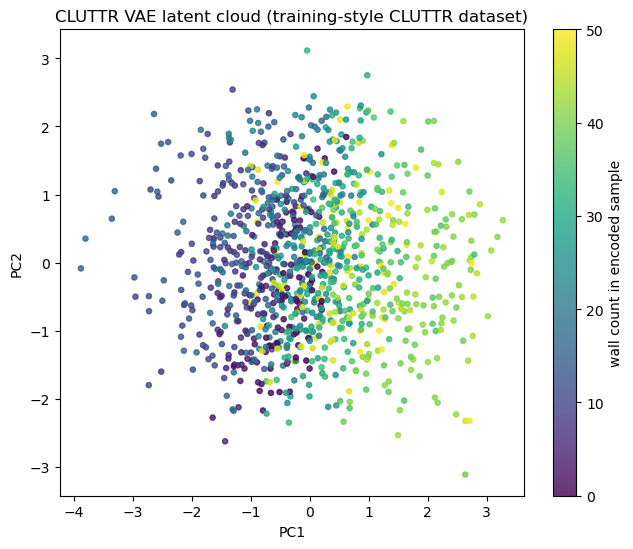

In [43]:
training_style_sequences = np.asarray(np.load(TRAINING_STYLE_DATASET_PATH, mmap_mode='r')[:1024], dtype=np.int32)
latent_cloud = encode_sequences(training_style_sequences, latent_mode=LATENT_MODE)
latent_center = latent_cloud.mean(axis=0, keepdims=True)
_, _, vh = np.linalg.svd(latent_cloud - latent_center, full_matrices=False)
PCA_BASIS = vh[:2].T.astype(np.float32)
PCA_COORDS = (latent_cloud - latent_center) @ PCA_BASIS

raw_decoded_preview = decode_latents(latent_cloud[:128], repair=False)
raw_decoder_health = summarize_raw_decoder_health(raw_decoded_preview)
decoded_preview = decode_latents(latent_cloud[:128], repair=True)
preview_summaries = [summarize_sequence(seq) for seq in decoded_preview]
preview_solve_rate = float(np.mean([item['solvable'] for item in preview_summaries]))
preview_avg_obs = float(np.mean([item['obstacles'] for item in preview_summaries]))

print('Latent mode =', LATENT_MODE)
print('Latent cloud shape =', latent_cloud.shape)
print('Raw decoder health =', raw_decoder_health)
print('Repaired preview solve rate =', preview_solve_rate)
print('Repaired preview avg obstacle count =', preview_avg_obs)

wall_counts = (training_style_sequences[:, :50] > 0).sum(axis=1)
plt.figure(figsize=(6.6, 5.6))
scatter = plt.scatter(PCA_COORDS[:, 0], PCA_COORDS[:, 1], c=wall_counts, cmap='viridis', s=14, alpha=0.8)
plt.colorbar(scatter, label='wall count in encoded sample')
plt.title('CLUTTR VAE latent cloud (training-style CLUTTR dataset)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.tight_layout()
plt.show()


## VAE Perturbation And Decoding Demo

The cell below picks one encoded maze as a latent anchor, decodes the anchor itself, and then decodes Gaussian perturbations around it. The decoded sequences are always repaired before being rendered as mazes.


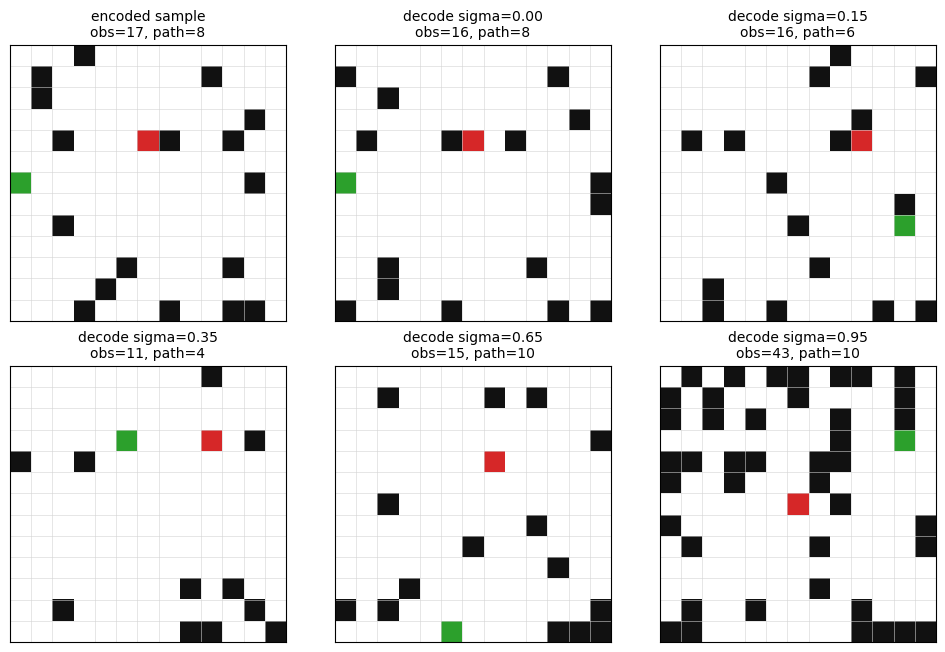

In [44]:
parent_sequence = training_style_sequences[PARENT_INDEX]
parent_latent = latent_cloud[PARENT_INDEX]
noise_rng = np.random.default_rng(7)
sigmas = [0.0, 0.15, 0.35, 0.65, 0.95]
latent_variants = []
for sigma in sigmas:
    if sigma == 0.0:
        latent_variants.append(parent_latent)
    else:
        latent_variants.append(parent_latent + sigma * noise_rng.normal(size=parent_latent.shape).astype(np.float32))
latent_variants = np.stack(latent_variants, axis=0)
decoded_variants = decode_latents(latent_variants, repair=True)

sequences_to_show = [parent_sequence] + list(decoded_variants)
titles = []
original_summary = summarize_sequence(parent_sequence)
titles.append(
    f"encoded sample\nobs={original_summary['obstacles']}, path={original_summary['path_length']}"
)
for sigma, seq in zip(sigmas, decoded_variants):
    summary = summarize_sequence(seq)
    titles.append(f"decode sigma={sigma:.2f}\nobs={summary['obstacles']}, path={summary['path_length']}")

plot_sequence_gallery(sequences_to_show, titles, ncols=3, figsize_scale=3.3)
plt.show()


## Lightweight CMA-ES Demo In A 2D Latent Plane

For an interactive search demo, we optimize in the top-2 PCA subspace around the anchor latent above.

- Search variable: a 2D coordinate in the PCA plane.
- Latent used for decoding: `anchor_latent + coord[0] * pc1 + coord[1] * pc2`.
- Notebook objective: a fast structural score that rewards solvable mazes with longer path length and more walls.

This keeps the demo fast. The full training pipeline uses agent-driven fitness instead.

In [45]:
anchor_global = np.asarray((parent_latent[None, :] - latent_center) @ PCA_BASIS, dtype=np.float32)[0]


def plane_to_latent(coords):
    coords = np.atleast_2d(np.asarray(coords, dtype=np.float32))
    return parent_latent[None, :] + coords @ PCA_BASIS.T


es = cma.CMAEvolutionStrategy([0.0, 0.0], 0.65, {'seed': 0, 'popsize': CMA_POPSIZE, 'verbose': -9, 'verb_disp': 0})
history = []
best_score = -np.inf
best_sequence = None
best_global = None

for step_idx in range(CMA_STEPS):
    solutions = np.asarray(es.ask(), dtype=np.float32)
    z_batch = plane_to_latent(solutions)
    decoded_batch = decode_latents(z_batch, repair=True)
    scores = np.asarray([score_sequence(seq) for seq in decoded_batch], dtype=np.float32)
    es.tell(solutions.tolist(), (-scores).tolist())

    population_global = np.asarray((z_batch - latent_center) @ PCA_BASIS, dtype=np.float32)
    mean_coords = np.asarray(es.mean, dtype=np.float32)
    mean_global = anchor_global + mean_coords

    step_best_idx = int(np.argmax(scores))
    if float(scores[step_best_idx]) > best_score:
        best_score = float(scores[step_best_idx])
        best_sequence = decoded_batch[step_best_idx].copy()
        best_global = population_global[step_best_idx].copy()

    history.append({
        'population_global': population_global,
        'scores': scores,
        'mean_global': mean_global,
        'best_global': best_global.copy(),
        'best_score': best_score,
        'step_best_sequence': decoded_batch[step_best_idx].copy(),
    })

best_path = []
frames = []
for step_idx, item in enumerate(history):
    best_path.append(item['best_global'])
    best_path_array = np.asarray(best_path)
    frames.append(
        go.Frame(
            name=str(step_idx),
            data=[
                go.Scatter(
                    x=PCA_COORDS[:, 0],
                    y=PCA_COORDS[:, 1],
                    mode='markers',
                    marker={'size': 5, 'color': 'rgba(120,120,120,0.22)'},
                    name='encoded dataset',
                ),
                go.Scatter(
                    x=item['population_global'][:, 0],
                    y=item['population_global'][:, 1],
                    mode='markers',
                    marker={
                        'size': 11,
                        'color': item['scores'],
                        'colorscale': 'Turbo',
                        'showscale': True,
                        'colorbar': {'title': 'score'},
                    },
                    name='population',
                ),
                go.Scatter(
                    x=best_path_array[:, 0],
                    y=best_path_array[:, 1],
                    mode='lines+markers',
                    marker={'size': 8, 'color': 'crimson'},
                    line={'color': 'crimson', 'width': 2},
                    name='best-so-far',
                ),
                go.Scatter(
                    x=[item['mean_global'][0]],
                    y=[item['mean_global'][1]],
                    mode='markers',
                    marker={'symbol': 'star', 'size': 18, 'color': 'black'},
                    name='search mean',
                ),
            ],
            layout=go.Layout(title=f"CMA-ES latent search iteration {step_idx + 1}/{CMA_STEPS} | best score={item['best_score']:.2f}")
        )
    )

cma_fig = go.Figure(data=frames[0].data, frames=frames)
cma_fig.update_layout(
    width=900,
    height=620,
    xaxis_title='PC1',
    yaxis_title='PC2',
    title='CMA-ES latent search in a 2D PCA plane',
    updatemenus=[{
        'type': 'buttons',
        'buttons': [
            {'label': 'Play', 'method': 'animate', 'args': [None, {'frame': {'duration': 700, 'redraw': True}, 'fromcurrent': True}]},
            {'label': 'Pause', 'method': 'animate', 'args': [[None], {'frame': {'duration': 0, 'redraw': False}, 'mode': 'immediate'}]},
        ],
    }],
    sliders=[{
        'currentvalue': {'prefix': 'Iteration '},
        'steps': [
            {'label': str(i + 1), 'method': 'animate', 'args': [[str(i)], {'frame': {'duration': 0, 'redraw': True}, 'mode': 'immediate'}]}
            for i in range(len(frames))
        ],
    }],
)
cma_fig


Best CMA-ES notebook score = 34.0
Start decoded summary = {'obstacles': 16, 'manhattan': 8, 'path_length': 8, 'solvable': True}
Best decoded summary = {'obstacles': 40, 'manhattan': 18, 'path_length': 20, 'solvable': True}


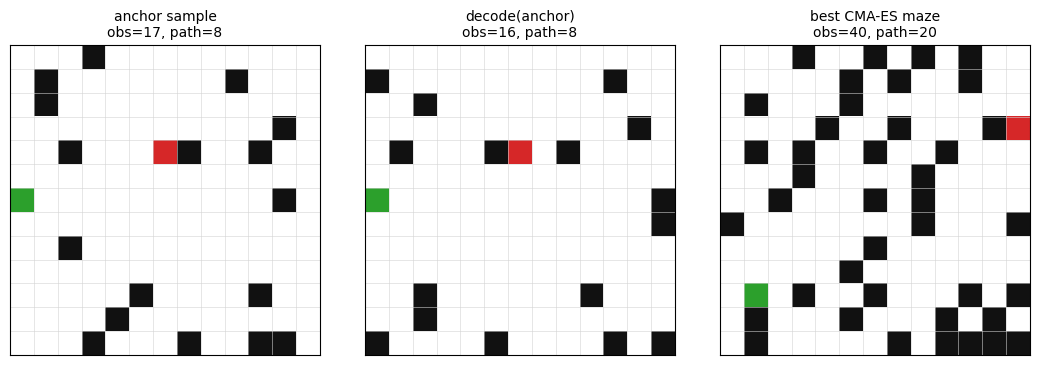

In [46]:
start_sequence = decode_latents(parent_latent[None, :], repair=True)[0]
start_summary = summarize_sequence(start_sequence)
best_summary = summarize_sequence(best_sequence)

print('Best CMA-ES notebook score =', best_score)
print('Start decoded summary =', start_summary)
print('Best decoded summary =', best_summary)

plot_sequence_gallery(
    [parent_sequence, start_sequence, best_sequence],
    [
        f"anchor sample\nobs={summarize_sequence(parent_sequence)['obstacles']}, path={summarize_sequence(parent_sequence)['path_length']}",
        f"decode(anchor)\nobs={start_summary['obstacles']}, path={start_summary['path_length']}",
        f"best CMA-ES maze\nobs={best_summary['obstacles']}, path={best_summary['path_length']}",
    ],
    ncols=3,
    figsize_scale=3.6,
)
plt.show()


## Evaluation of A Trained Agent On The Held Out Test Mazes

The cell below evaluates a deterministic policy on the fixed prefab test mazes from the repo. By default it uses:

`checkpoints/accel_baseline_seed0/0/models`

To use a different agent, change `AGENT_CHECKPOINT_DIR` in the config cell near the top of the notebook.


Loading agent checkpoint from /Users/khyledhanani/Documents/openend/superintelligence/notebooks/assets/models (step=44)
Agent contract test PASSED: obs(5,5,3) -> 7 actions, value shape=(1, 1)
Solve rate = 0.6666666666666666
Mean return = 0.3798666298389435
[('NarrowBridge', 0.2871999740600586), ('ForkDeception', 0.6651999950408936), ('PerimeterRun', 0.8091999888420105), ('SpiralPocket', 0.39879998564720154), ('SymmetricCross', 0.5284000039100647), ('ZigZagTunnel', 0.0), ('RoomKeyhole', 0.0), ('DualLoopChoice', 0.3267999589443207), ('CentralChoke', 0.848800003528595), ('LongDetour', 0.0), ('DeadendFan', 0.7731999754905701), ('OpenFieldBarriers', 0.45639997720718384), ('ParallelCorridors', 0.0), ('CornerTrapEscape', 0.6039999723434448), ('SnakeSpine', 0.0)]


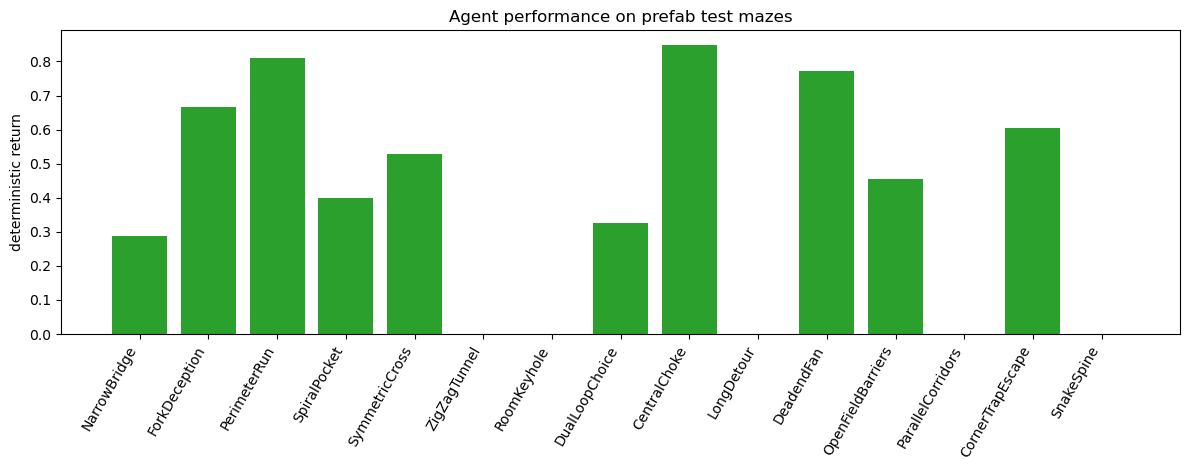

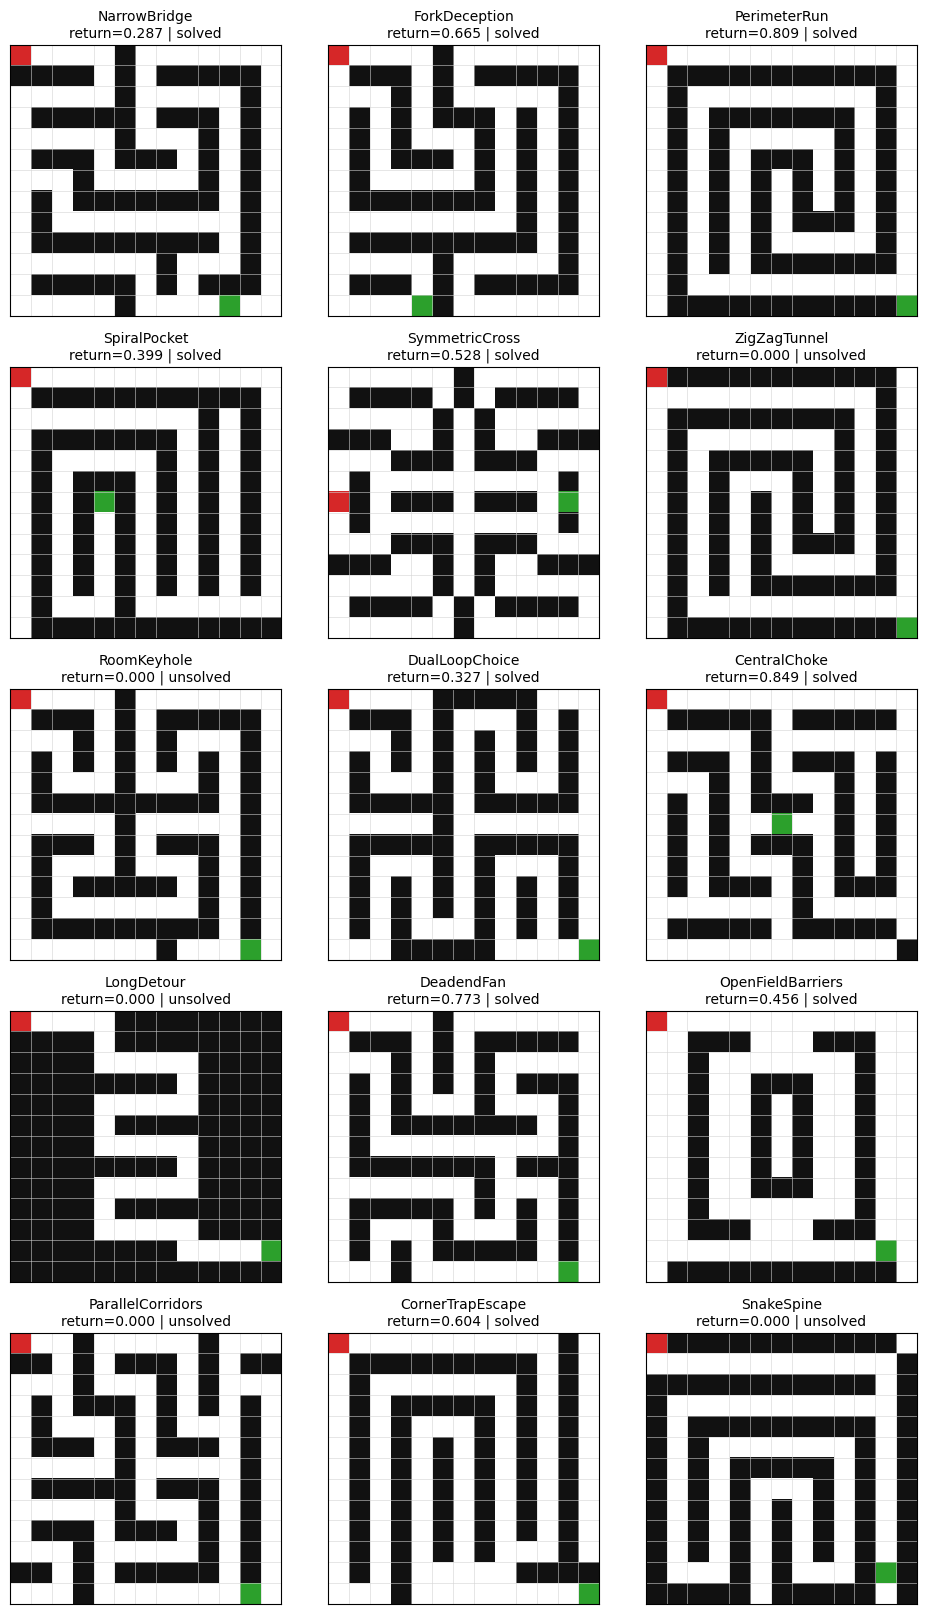

In [47]:
def evaluate_agent_on_prefabs(checkpoint_dir, level_names, rollout_steps=ROLLOUT_STEPS):
    levels = [Level.from_str(prefabs[name]) for name in level_names]
    stacked_levels = Level.stack(levels)

    agent_params, network = load_agent(str(checkpoint_dir))
    env = Maze(max_height=13, max_width=13, agent_view_size=5, normalize_obs=True)
    env_params = env.default_params.replace(max_steps_in_episode=rollout_steps)

    rng_reset = jax.random.PRNGKey(0)
    init_obs, init_state = jax.vmap(env.reset_to_level, in_axes=(0, 0, None))(
        jax.random.split(rng_reset, len(level_names)), stacked_levels, env_params
    )
    verify_agent_contract(agent_params, network)

    @jax.jit
    def rollout(params, obs0, state0):
        def step_fn(carry, _):
            rng, hstate, obs, state, done, mask, returns = carry
            rng, _, step_rng = jax.random.split(rng, 3)
            x = jax.tree_util.tree_map(lambda a: a[None, ...], (obs, done))
            hstate, pi, _ = network.apply({'params': params}, x, hstate)
            action = pi.mode().squeeze(0)
            next_obs, next_state, reward, next_done, _ = jax.vmap(env.step, in_axes=(0, 0, 0, None))(
                jax.random.split(step_rng, action.shape[0]), state, action, env_params
            )
            active = mask & (~done)
            returns = returns + reward * active
            next_mask = mask & (~next_done)
            return (rng, hstate, next_obs, next_state, next_done, next_mask, returns), None

        init_h = ActorCritic.initialize_carry((len(level_names),))
        init_done = jnp.zeros((len(level_names),), dtype=jnp.bool_)
        init_mask = jnp.ones((len(level_names),), dtype=jnp.bool_)
        init_returns = jnp.zeros((len(level_names),), dtype=jnp.float32)
        final_carry, _ = jax.lax.scan(
            step_fn,
            (jax.random.PRNGKey(123), init_h, obs0, state0, init_done, init_mask, init_returns),
            None,
            length=rollout_steps,
        )
        return final_carry[-1]

    returns = np.asarray(rollout(agent_params, init_obs, init_state), dtype=np.float32)
    solved = returns > 0
    return {
        'levels': levels,
        'names': list(level_names),
        'returns': returns,
        'solved': solved,
        'solve_rate': float(np.mean(solved)),
        'mean_return': float(np.mean(returns)),
    }


agent_results = evaluate_agent_on_prefabs(AGENT_CHECKPOINT_DIR, TEST_LEVEL_NAMES)
print('Solve rate =', agent_results['solve_rate'])
print('Mean return =', agent_results['mean_return'])
print(list(zip(agent_results['names'], agent_results['returns'].tolist())))

colors = ['#2ca02c' if solved else '#d62728' for solved in agent_results['solved']]
plt.figure(figsize=(12, 4.8))
plt.bar(agent_results['names'], agent_results['returns'], color=colors)
plt.xticks(rotation=60, ha='right')
plt.ylabel('deterministic return')
plt.title('Agent performance on prefab test mazes')
plt.tight_layout()
plt.show()

gallery_titles = []
for name, ret, solved in zip(agent_results['names'], agent_results['returns'], agent_results['solved']):
    status = 'solved' if solved else 'unsolved'
    gallery_titles.append(f'{name}\nreturn={ret:.3f} | {status}')

plot_level_gallery(agent_results['levels'], gallery_titles, ncols=3, figsize_scale=3.25)
plt.show()
